In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import svm
import seaborn as sns

In [2]:
Loan=pd.read_csv("C:/Users/ishwa/ML/Loan_dataset/train_u6lujuX_CVtuZ9i (1).csv")

In [3]:
Loan.head()
Loan=Loan.drop(columns="Loan_ID",axis=1)

In [4]:
Loan.shape

(614, 12)

In [5]:
Loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [6]:
Loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Check if there are Null value or not if yest either remove it or fill ('') empyt values

In [7]:
print(Loan.shape)
Loan.isnull().sum()

(614, 12)


Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
#drop missing values whole row
Loan=Loan.dropna()
Loan.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [9]:
print(Loan.shape)


(480, 12)


In [10]:
#Replace Y and N with 0 and 1
Loan.replace({'Loan_Status':{'Y':1,"N":0}},inplace=True)


C:\Users\ishwa\AppData\Local\Temp\ipykernel_17708\3755553204.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Loan.replace({'Loan_Status':{'Y':1,"N":0}},inplace=True)


In [11]:
print(Loan.head())

  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
1   Male     Yes          1      Graduate            No             4583   
2   Male     Yes          0      Graduate           Yes             3000   
3   Male     Yes          0  Not Graduate            No             2583   
4   Male      No          0      Graduate            No             6000   
5   Male     Yes          2      Graduate           Yes             5417   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   
5             4196.0       267.0             360.0             1.0   

  Property_Area  Loan_Status  
1         Rural            0  
2         Urban            1  
3         Urban            1 

In [12]:
Loan['Dependents'].value_counts()

Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [13]:
Loan.replace({'Dependents':{'3+':4}},inplace=True)
Loan['Dependents'] = pd.to_numeric(Loan['Dependents'])
print(Loan)

     Gender Married  Dependents     Education Self_Employed  ApplicantIncome  \
1      Male     Yes           1      Graduate            No             4583   
2      Male     Yes           0      Graduate           Yes             3000   
3      Male     Yes           0  Not Graduate            No             2583   
4      Male      No           0      Graduate            No             6000   
5      Male     Yes           2      Graduate           Yes             5417   
..      ...     ...         ...           ...           ...              ...   
609  Female      No           0      Graduate            No             2900   
610    Male     Yes           4      Graduate            No             4106   
611    Male     Yes           1      Graduate            No             8072   
612    Male     Yes           2      Graduate            No             7583   
613  Female      No           0      Graduate           Yes             4583   

     CoapplicantIncome  LoanAmount  Loa

Data Vizualization

<Axes: xlabel='Education', ylabel='count'>

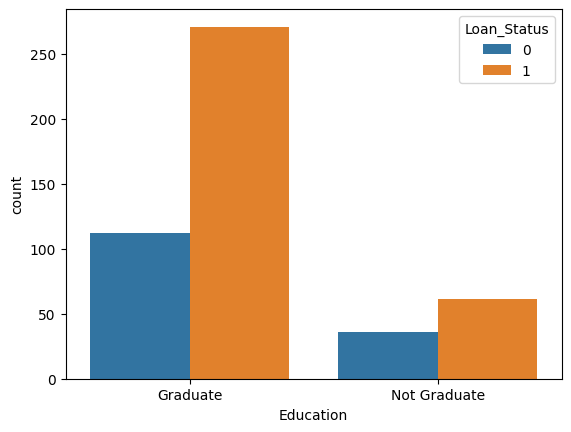

In [14]:
#chcking the relation Between Education and Loan_status
sns.countplot(x="Education", hue="Loan_Status", data=Loan)

<Axes: xlabel='Credit_History', ylabel='count'>

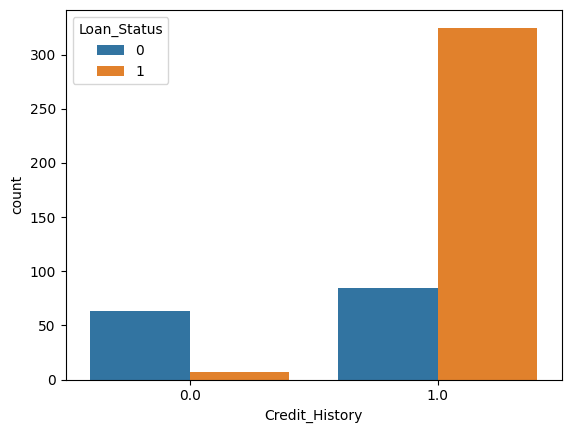

In [15]:
sns.countplot(x="Credit_History", hue="Loan_Status", data=Loan)

Heatmap for correlation of all .corr()

import matplotlib.pyplot as plt

correlation = Loan.corr()

sns.heatmap(correlation, annot=True, cmap='Blues')

plt.show()

This didnt work bcuz Heatmap except only the numbers and TEXT where it expected NUMBERS

Covert Text Like Male=1, Female=0 ,Yes on married =1 and Not_married=0 eductation Graduate=1 not_graduate=0 slef emplayed Yes=1 and No=0

In [16]:
Loan.replace({"Gender":{'Male':1,'Female':0}},inplace=True)

C:\Users\ishwa\AppData\Local\Temp\ipykernel_17708\2407672787.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Loan.replace({"Gender":{'Male':1,'Female':0}},inplace=True)


In [17]:
Loan.replace({'Education':{'Graduate':1,'Not Graduate':0}}, inplace=True)

C:\Users\ishwa\AppData\Local\Temp\ipykernel_17708\37071457.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Loan.replace({'Education':{'Graduate':1,'Not Graduate':0}}, inplace=True)


In [18]:
Loan.replace({'Self_Employed':{'Yes':1,"No":0}},inplace=True)


C:\Users\ishwa\AppData\Local\Temp\ipykernel_17708\2561974642.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Loan.replace({'Self_Employed':{'Yes':1,"No":0}},inplace=True)


In [19]:
Loan.replace({'Married':{'Yes':1,"No":0}},inplace=True)


C:\Users\ishwa\AppData\Local\Temp\ipykernel_17708\606325071.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Loan.replace({'Married':{'Yes':1,"No":0}},inplace=True)


In [20]:
print(Loan.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
1       1        1           1          1              0             4583   
2       1        1           0          1              1             3000   
3       1        1           0          0              0             2583   
4       1        0           0          1              0             6000   
5       1        1           2          1              1             5417   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   
5             4196.0       267.0             360.0             1.0   

  Property_Area  Loan_Status  
1         Rural            0  
2         Urban            1  
3         Urban        

In [21]:
print(Loan.dtypes)

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status            int64
dtype: object


In [22]:
Loan['Dependents'] = pd.to_numeric(Loan['Dependents'])

In [23]:
Loan.replace({
    'Property_Area': {
        'Rural':0,
        'Semiurban':1,
        'Urban':2
    }
}, inplace=True)

C:\Users\ishwa\AppData\Local\Temp\ipykernel_17708\523374732.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Loan.replace({


spliting x(input variable) and Y (Label/traget)

In [24]:
x=Loan.drop(columns="Loan_Status",axis=1)
print(x)

     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
1         1        1           1          1              0             4583   
2         1        1           0          1              1             3000   
3         1        1           0          0              0             2583   
4         1        0           0          1              0             6000   
5         1        1           2          1              1             5417   
..      ...      ...         ...        ...            ...              ...   
609       0        0           0          1              0             2900   
610       1        1           4          1              0             4106   
611       1        1           1          1              0             8072   
612       1        1           2          1              0             7583   
613       0        0           0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

In [25]:
y=Loan['Loan_Status']
print(y)

1      0
2      1
3      1
4      1
5      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 480, dtype: int64


In [26]:
print(x.isnull().sum())
print("check Null vAlues of Y")
print(y.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64
check Null vAlues of Y
0


Now we do the traing and testing part

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=6,stratify=y)

In [28]:
print(x_train.head(),x_test.head(),y_train.head(),y_test.head())

     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
456       1        1           0          1              0             4301   
70        1        1           0          1              0             3208   
339       0        0           0          1              0             4160   
80        0        0           0          1              0             3846   
438       1        0           0          1              1            10416   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
456                0.0       118.0             360.0             1.0   
70              3066.0       172.0             360.0             1.0   
339                0.0        71.0             360.0             1.0   
80                 0.0       111.0             360.0             1.0   
438                0.0       187.0             360.0             0.0   

     Property_Area  
456              2  
70               2  
339              1  
80      

In [29]:
print(x_train.isnull().sum(),x_test.isnull().sum(),y_train.isnull().sum(),y_test.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64 0 0


Training  The Train Values Data

In [30]:
#traning Data


model=svm.SVC(kernel="linear")

In [31]:
model.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Model Evaluation:Accuracy Of Our Model

In [32]:
x_pred = model.predict(x_train)

training_data_accuracy = accuracy_score(x_pred, y_train)

print(training_data_accuracy)

0.7682291666666666


In [33]:
x_pred_test = model.predict(x_test)

test_data_accuracy = accuracy_score(x_pred_test, y_test)

print(test_data_accuracy)

0.8020833333333334


Makaing A Prdictive Sysytem

In [52]:
input = (1,1,0,1,0,5000,2000,110,310,1,1)

input_as_numpy_array = np.asarray(input)

input_reshaped = input_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_reshaped)

print(prediction)

if prediction[0] == 1:
    print("Loan is eligible")
else:
    print("Loan not eligible")

[1]
Loan is eligible


C:\Users\ishwa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
